# Audio Speaker Labeling

Demonstrates how `build_labeled_audio()` in `pipelines.py` assigns candidate names
to every audio segment across all 28 debates.

**Two-stage pipeline:**
1. **k=3 per-debate clustering** — speaker embeddings (512-d pyannote vectors) are
   clustered into 3 groups per debate: candidate A, candidate B, host.
2. **Cross-debate centroid anchoring** — each candidate appears in 7 debates. Their
   cluster centroid should be consistent across those 7. We find the best-matching
   centroid per candidate per debate, average them into a global centroid, then
   re-assign labels using cosine distance to that global centroid.

## Setup

In [1]:
import sys, os
# works whether Jupyter is started from project root or from a subfolder
sys.path.insert(0, 'multivideo_analysis')
sys.path.insert(0, '../multivideo_analysis')
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist

%load_ext autoreload
%autoreload 2
from pipelines import build_labeled_audio, CANDIDATES, CAND_COLOR, extract_candidates

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

DEMO_DEBATE = 'Martins_vs_Gouveia_Melo_November_23'

## Step 1 — Speaker embeddings

In [2]:
data = build_labeled_audio()
debate_videos = sorted(v for v in data['video'].unique() if 'vs' in v)

# Focus on one demo debate first
demo = data[data['video'] == DEMO_DEBATE].copy()
E = np.stack(demo['speak_embeddings'].values)
print(f'Debate: {DEMO_DEBATE}')
print(f'Segments: {len(demo)} | Embedding shape: {E.shape}')
print(demo['speaker'].value_counts())

build_labeled_audio: 2656 segments | 28 debates | 9 unique speakers
Debate: Martins_vs_Gouveia_Melo_November_23
Segments: 99 | Embedding shape: (99, 512)
speaker
Gouveia_Melo    57
Martins         26
host            16
Name: count, dtype: int64


## Step 2 — Elbow curve + silhouette for one debate (K=3)

Each debate has exactly 3 speakers: candidate A, candidate B, host.

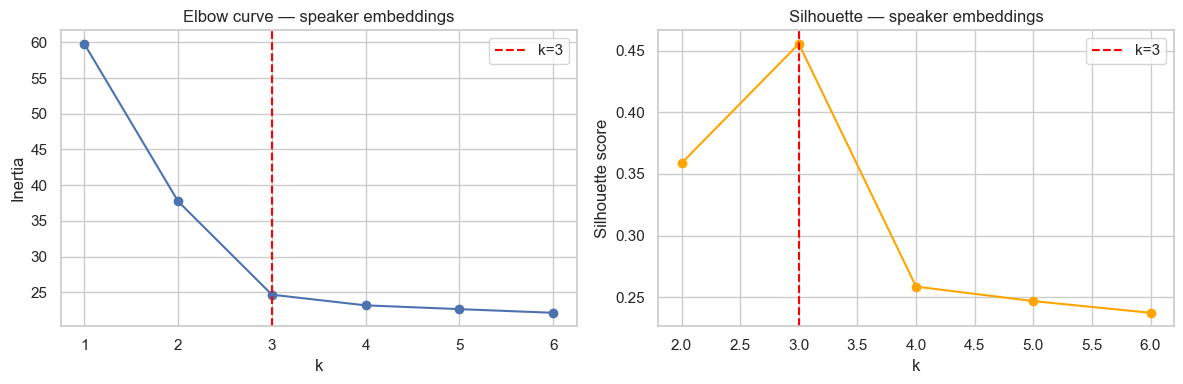

In [3]:
E_raw = np.stack(demo['speak_embeddings'].values)

# Elbow
inertias = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(E_raw).inertia_
            for k in range(1, 7)]

# Silhouette (needs k >= 2)
sil = [silhouette_score(E_raw, KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(E_raw))
       for k in range(2, 7)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(range(1, 7), inertias, marker='o')
ax1.axvline(3, color='red', ls='--', label='k=3')
ax1.set_xlabel('k'); ax1.set_ylabel('Inertia')
ax1.set_title('Elbow curve — speaker embeddings'); ax1.legend()

ax2.plot(range(2, 7), sil, marker='o', color='orange')
ax2.axvline(3, color='red', ls='--', label='k=3')
ax2.set_xlabel('k'); ax2.set_ylabel('Silhouette score')
ax2.set_title('Silhouette — speaker embeddings'); ax2.legend()

plt.tight_layout(); plt.show()

## Step 3 — k=3 clusters in PCA space (one debate)

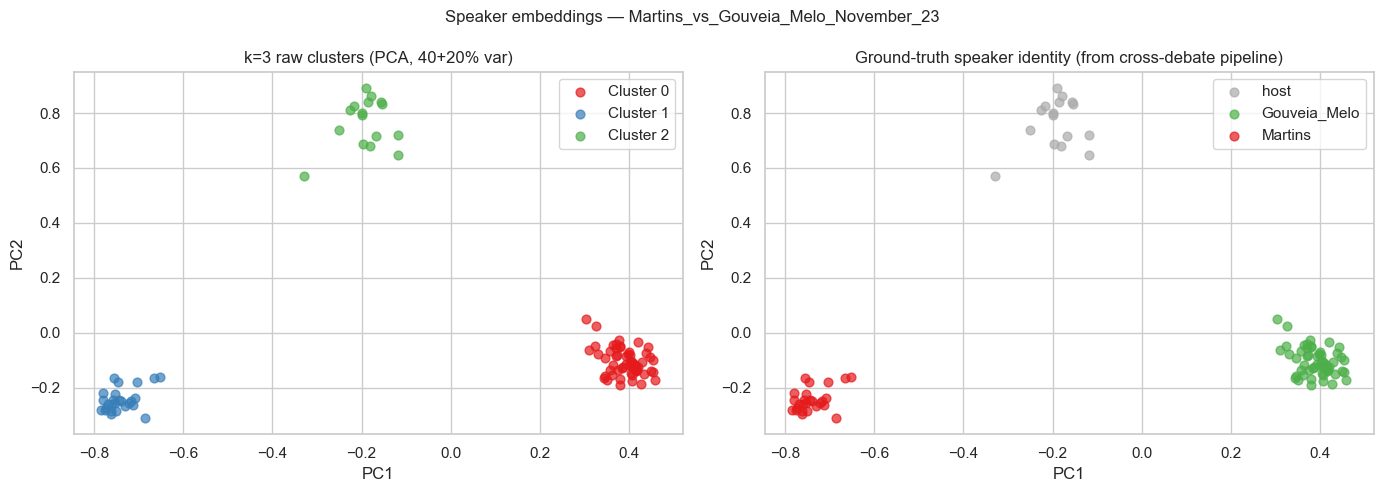

In [4]:
km = KMeans(n_clusters=3, random_state=42, n_init=10)
raw_labels = km.fit_predict(E_raw)

pca = PCA(n_components=2, random_state=42)
E_2d = pca.fit_transform(E_raw)
v1, v2 = pca.explained_variance_ratio_ * 100

cmap = {0: '#e41a1c', 1: '#377eb8', 2: '#4daf4a'}
true_colors = [CAND_COLOR.get(s, '#aaaaaa') for s in demo['speaker']]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for ki in range(3):
    m = raw_labels == ki
    ax1.scatter(E_2d[m, 0], E_2d[m, 1], c=cmap[ki], alpha=0.7, s=40, label=f'Cluster {ki}')
ax1.set_title(f'k=3 raw clusters (PCA, {v1:.0f}+{v2:.0f}% var)')
ax1.set_xlabel('PC1'); ax1.set_ylabel('PC2'); ax1.legend()

for spk in demo['speaker'].unique():
    m = demo['speaker'] == spk
    c = CAND_COLOR.get(spk, '#aaaaaa')
    ax2.scatter(E_2d[m.values, 0], E_2d[m.values, 1], c=c, alpha=0.7, s=40, label=spk)
ax2.set_title('Ground-truth speaker identity (from cross-debate pipeline)')
ax2.set_xlabel('PC1'); ax2.set_ylabel('PC2'); ax2.legend()

plt.suptitle(f'Speaker embeddings — {DEMO_DEBATE}', fontsize=12)
plt.tight_layout(); plt.show()

## Step 4 — Silhouette across all 28 debates

A high silhouette score means the 3 speakers are well-separated in embedding space
for that debate. Low scores (< 0.25) flag debates where labels may be unreliable.

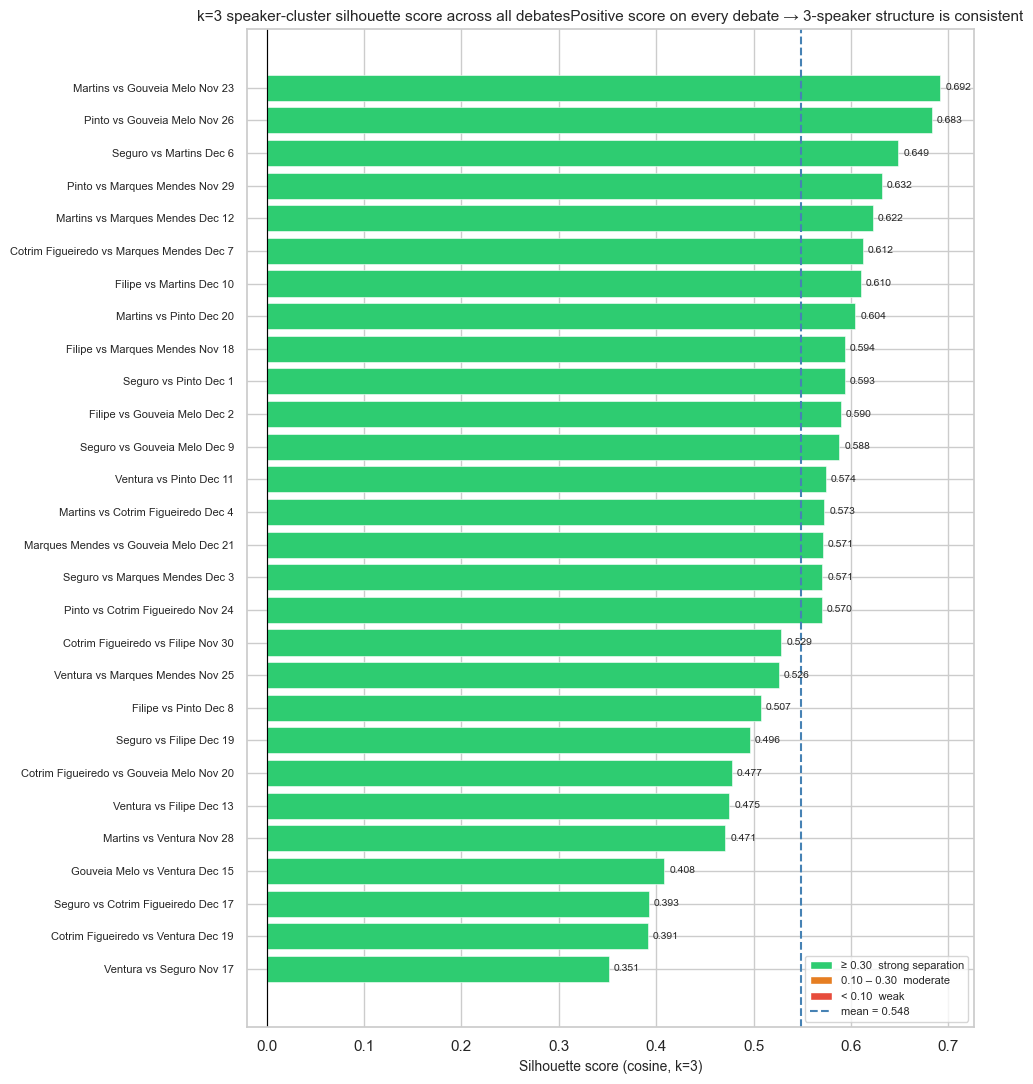

Debates: 28 | mean: 0.548 | median: 0.572
Strong (>=0.30): 28 | Moderate (0.10-0.30): 0 | Weak (<0.10): 0


In [5]:
sil_rows = []
for v in debate_videos:
    sub = data[data['video'] == v]
    if len(sub) < 4:
        continue
    E_v = np.stack(sub['speak_embeddings'].values)
    km  = KMeans(n_clusters=3, random_state=42, n_init=10)
    lbl = km.fit_predict(E_v)
    if len(np.unique(lbl)) < 3:
        continue
    s = silhouette_score(E_v, lbl, metric='cosine')
    sil_rows.append({
        'debate': (v.replace('_vs_', ' vs ').replace('_', ' ')
                    .replace('November', 'Nov').replace('December', 'Dec')),
        'silhouette': s,
        'n_segments': len(sub),
    })

sil_df   = pd.DataFrame(sil_rows).sort_values('silhouette', ascending=True).reset_index(drop=True)
mean_sil = sil_df['silhouette'].mean()

bar_colors = ['#2ecc71' if s >= 0.3 else '#e67e22' if s >= 0.1 else '#e74c3c'
              for s in sil_df['silhouette']]

fig, ax = plt.subplots(figsize=(10, 11))
bars = ax.barh(sil_df['debate'], sil_df['silhouette'], color=bar_colors,
               edgecolor='white', linewidth=0.4)
ax.axvline(mean_sil, color='steelblue', ls='--', lw=1.5, label=f'mean = {mean_sil:.3f}')
ax.axvline(0, color='black', lw=0.8)

for bar, val in zip(bars, sil_df['silhouette']):
    ax.text(max(val + 0.005, 0.005), bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', ha='left', fontsize=7.5)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='≥ 0.30  strong separation'),
    Patch(facecolor='#e67e22', label='0.10 – 0.30  moderate'),
    Patch(facecolor='#e74c3c', label='< 0.10  weak'),
    plt.Line2D([0], [0], color='steelblue', ls='--', lw=1.5, label=f'mean = {mean_sil:.3f}'),
]
ax.legend(handles=legend_elements, fontsize=8, loc='lower right')
ax.set_xlabel('Silhouette score (cosine, k=3)', fontsize=10)
ax.set_title('k=3 speaker-cluster silhouette score across all debates''Positive score on every debate → 3-speaker structure is consistent', fontsize=11)
ax.tick_params(axis='y', labelsize=8)
ax.set_xlim(left=min(sil_df['silhouette'].min() - 0.05, -0.02))
plt.tight_layout()
plt.show()

print(f'Debates: {len(sil_df)} | mean: {mean_sil:.3f} | median: {sil_df["silhouette"].median():.3f}')
print(f'Strong (>=0.30): {(sil_df["silhouette"] >= 0.30).sum()} | '
      f'Moderate (0.10-0.30): {((sil_df["silhouette"] >= 0.10) & (sil_df["silhouette"] < 0.30)).sum()} | '
      f'Weak (<0.10): {(sil_df["silhouette"] < 0.10).sum()}')

## Step 5 — Voice consistency across debates

Each candidate appears in 7 debates. Left panel: how close each candidate's per-debate voice centroids are to their own global centroid — how consistent they sound across appearances. Right panel: how far that centroid sits from the nearest other candidate.

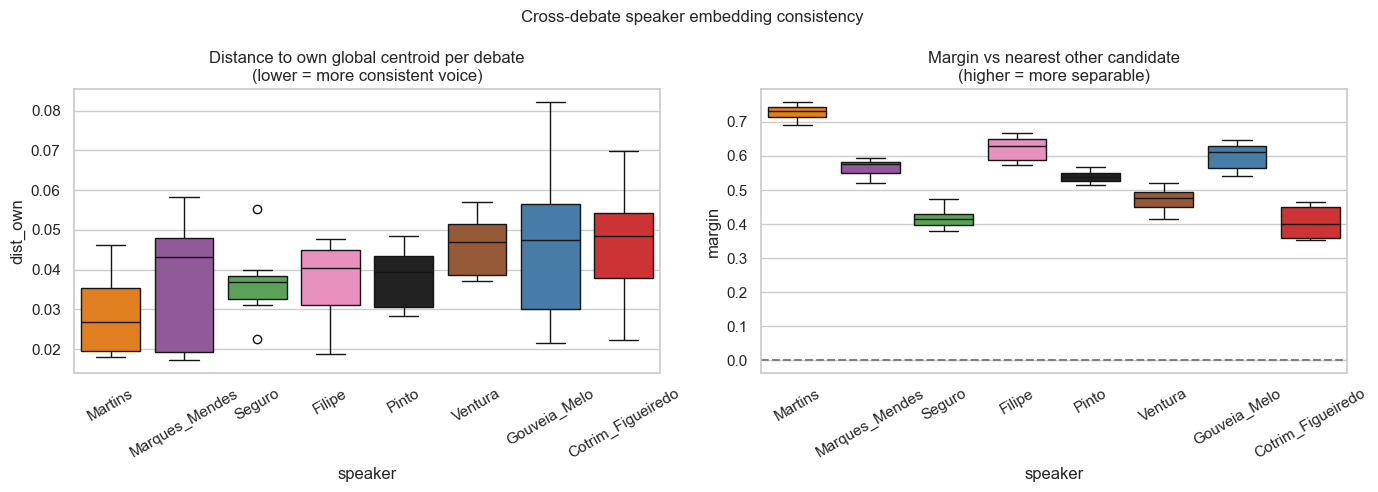

In [6]:
# Show global centroid consistency: for each candidate, how far are their
# per-debate centroids from their own global centroid vs other candidates?

cand_data = data[data['speaker'].isin(CANDIDATES)].copy()

cand_debate_rows = []
for (spk, vid), grp in cand_data.groupby(['speaker', 'video']):
    E = np.stack(grp['speak_embeddings'].values)
    cand_debate_rows.append({'speaker': spk, 'video': vid, 'centroid': E.mean(axis=0)})

cdt = pd.DataFrame(cand_debate_rows)
global_c = cdt.groupby('speaker')['centroid'].apply(
    lambda s: np.mean(np.stack(s.values), axis=0))

rows = []
for _, r in cdt.iterrows():
    d_own   = cdist(r['centroid'][None,:], global_c[r['speaker']][None,:], metric='cosine')[0,0]
    others  = [c for c in global_c.index if c != r['speaker']]
    d_other = cdist(r['centroid'][None,:],
                    np.stack(global_c[others].values), metric='cosine')[0].min()
    rows.append({'speaker': r['speaker'], 'dist_own': d_own, 'dist_nearest_other': d_other,
                 'margin': d_other - d_own})

margin_df = pd.DataFrame(rows)
order = margin_df.groupby('speaker')['dist_own'].mean().sort_values().index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=margin_df, x='speaker', y='dist_own', order=order, hue ="speaker", palette=[CAND_COLOR[c] for c in order], ax=axes[0], legend=False)
axes[0].set_title('Distance to own global centroid per debate\n(lower = more consistent voice)')
axes[0].tick_params(axis='x', rotation=30)
sns.boxplot(data=margin_df, x='speaker', y='margin', order=order, hue="speaker",palette=[CAND_COLOR[c] for c in order], ax=axes[1], legend=False)
axes[1].axhline(0, color='grey', ls='--')
axes[1].set_title('Margin vs nearest other candidate\n(higher = more separable)')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Cross-debate speaker embedding consistency', fontsize=12)
plt.tight_layout(); plt.show()